<a href="https://colab.research.google.com/github/jooyoung227/ESAA-14-23-/blob/main/ESAA_jooyoung_YB_0320_study_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#시계열 데이터
# 12-1 datetime 오브젝트
- date 오브젝트: 날짜 처리
- time 오브젝트: 시간 처리
- datetime 오브젝트: 날짜와 시간 처리

In [3]:
from datetime import datetime

In [4]:
now1 = datetime.now()
print(now1)

2026-03-21 08:36:34.147003


In [5]:

now2 = datetime.today()
print(now2)

2026-03-21 08:36:35.609939


In [6]:
t1 = datetime.now()
t2 = datetime(1970, 1, 1)
t3 = datetime(1970, 12, 12, 13, 24, 34)

print(t1)
print(t2)
print(t3)

2026-03-21 08:36:36.288625
1970-01-01 00:00:00
1970-12-12 13:24:34


In [8]:
diff1 = t1 - t2

print(diff1)
print(type(diff1))

20533 days, 8:36:36.288625
<class 'datetime.timedelta'>


In [9]:
diff2 = t2 - t1

print(diff2)
print(type(diff2))

-20534 days, 15:23:23.711375
<class 'datetime.timedelta'>


###datetime 오브젝트로 변환하기 - to_datetime 메서드
시계열 데이터를 문자열로 저장해야 하는 상황에서 문자열은 시간 계산을 할 수 없으므로 datetime 오브젝트로 변환이 필요함

In [13]:
from google.colab import files
uploaded = files.upload()

Saving country_timeseries.csv to country_timeseries.csv


In [16]:
#문자열을 datetime 오브젝트로 변환하기
import pandas as pd
import os

ebola = pd.read_csv('country_timeseries.csv')

In [17]:
print(ebola.info( ))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 122 non-null    object 
 1   Day                  122 non-null    int64  
 2   Cases_Guinea         93 non-null     float64
 3   Cases_Liberia        83 non-null     float64
 4   Cases_SierraLeone    87 non-null     float64
 5   Cases_Nigeria        38 non-null     float64
 6   Cases_Senegal        25 non-null     float64
 7   Cases_UnitedStates   18 non-null     float64
 8   Cases_Spain          16 non-null     float64
 9   Cases_Mali           12 non-null     float64
 10  Deaths_Guinea        92 non-null     float64
 11  Deaths_Liberia       81 non-null     float64
 12  Deaths_SierraLeone   87 non-null     float64
 13  Deaths_Nigeria       38 non-null     float64
 14  Deaths_Senegal       22 non-null     float64
 15  Deaths_UnitedStates  18 non-null     flo

문자열로 저장된 Date 열이 있음  
to_datetime 메서드를 활용하여 Date 열의 자료형을 datetime 오브젝트로 변환

In [18]:
ebola['date_dt']=pd.to_datetime(ebola['Date'])
print(ebola.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

to_datetime 메서드를 활용하여 시간 형식 지정자와 기호를 적절히 조합하여 format 인자에 전달하면 그 형식에 맞게 정리된 datetime 오브젝트를 얻을 수 있음

In [22]:
test_df1 = pd.DataFrame({'order_day':['01/01/15', '02/01/15', '03/01/15']})

test_df1['date_dt1'] = pd.to_datetime(test_df1['order_day'], format='%d/%m/%y')
test_df1['date_dt2'] = pd.to_datetime(test_df1['order_day'], format='%d/%m/%y')
test_df1['date_dt3'] = pd.to_datetime(test_df1['order_day'], format='%d/%m/%y')

print(test_df1)

  order_day   date_dt1   date_dt2   date_dt3
0  01/01/15 2015-01-01 2015-01-01 2015-01-01
1  02/01/15 2015-01-02 2015-01-02 2015-01-02
2  03/01/15 2015-01-03 2015-01-03 2015-01-03


In [24]:
test_df2 = pd.DataFrame({'order_day':['01-01-15', '02-01-15', '03-01-15']})
test_df2 ['date_dt'] = pd.to_datetime(test_df2['order_day'], format='%d-%m-%y')

print(test_df2)

  order_day    date_dt
0  01-01-15 2015-01-01
1  02-01-15 2015-01-02
2  03-01-15 2015-01-03


###시간 형식 지정자

%a - 요일 출력  
%A - 요일 출력(긴 이름)  
%w - 요일 출력(숫자, 0부터 일요일)  
%d - 날짜 출력(2자리로 표시)  
%b - 월 출력  
%B - 월 출력(긴 이름)  
%m - 월 출력(숫자)  
%y - 년 출력(2자리로 표시)  
%Y - 년 출력(4자리로 표시)  
%H - 시간 출력(24시간)  
%I - 시간 출력(12시간)  
%p - AM 또는 PM 출력
%M - 분 출력(2자리로 표시)  
%S - 초 출력(2자리로 표시)  
%f - 마이크로초 출력  
%z - UTC 차이 출력(+HHMM이나 -HHMM형태)  
%Z - 기준 지역 이름 출력  
%j- 올해의 지난 일 수 출력(1일, 2일, ...)  
%U - 올해의 지난 주 수 출력(1주, 2주, ...)  
%c - 날짜와 시간 출력  
%x - 날짜 출력
%X - 시간 출력  
%G - 년 출력(ISO 8601 형식)  
%u - 요일 출력(ISO 8601 형식)  
%V - 올해의 지난 주 수 출력(ISO 8601 형식)

In [25]:
now = datetime.now()
print(now)

2026-03-21 09:11:40.638165


In [26]:
nowDate = now.strftime('%Y-%m-%d')
print(nowDate)

2026-03-21


In [27]:
nowTime = now.strftime('%H-%M-%S')
print(nowTime)

09-11-40


In [28]:
nowDatetime = now.strftime('%Y-%m-%d %H:%M:%S')
print(nowDatetime)

2026-03-21 09:11:40


###datetime 오브젝트로 변환하기 - read_csv 메서드

In [29]:
#datetime 오브젝트로 변환하려는 열을 지정하여 데이터 집합 불러오기
ebola1 = pd.read_csv('country_timeseries.csv', parse_dates=['Date'])
print(ebola1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    datetime64[ns]
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

###datetime 오브젝트에서 날짜 정보 추출하기

In [30]:
date_series = pd.Series(['2018-05-16', '2018-05-17', '2018-05-18'])
d1 = pd.to_datetime(date_series)
print(d1)

0   2018-05-16
1   2018-05-17
2   2018-05-18
dtype: datetime64[ns]


In [31]:
print(d1[0].year)
print(d1[0].month)
print(d1[0].day)

2018
5
16


df 접근자를 사용하면 datetime 속성이나 메서드를 사용해서 시계열 데이터를 처리할 수 있음

In [32]:
#df 접근자로 시계열 데이터 정리하기
ebola = pd.read_csv('country_timeseries.csv')
ebola['date_dt'] = pd.to_datetime(ebola['Date'])

In [33]:
print(ebola[['Date', 'date_dt']].head())

         Date    date_dt
0    1/5/2015 2015-01-05
1    1/4/2015 2015-01-04
2    1/3/2015 2015-01-03
3    1/2/2015 2015-01-02
4  12/31/2014 2014-12-31


In [34]:
print(ebola['date_dt'][3].year)
print(ebola['date_dt'][3].month)
print(ebola['date_dt'][3].day)

2015
1
2


In [35]:
#dt 접근자로 date_dt 열에 한 번에 접근한 다옴 year 속성을 이용하여 연도 값을 추출해보자
ebola['year'] = ebola['date_dt'].dt.year
print(ebola[['Date', 'date_dt', 'year']].head())

         Date    date_dt  year
0    1/5/2015 2015-01-05  2015
1    1/4/2015 2015-01-04  2015
2    1/3/2015 2015-01-03  2015
3    1/2/2015 2015-01-02  2015
4  12/31/2014 2014-12-31  2014


In [36]:
#위를 응용하여 월, 일 데이터를 한번에 추출해 새로운 열로 추가
ebola['month'], ebola['day'] = (ebola['date_dt'].dt.month, ebola['date_dt'].dt.day)
print(ebola[['Date','date_dt', 'year', 'month', 'day']].head())

         Date    date_dt  year  month  day
0    1/5/2015 2015-01-05  2015      1    5
1    1/4/2015 2015-01-04  2015      1    4
2    1/3/2015 2015-01-03  2015      1    3
3    1/2/2015 2015-01-02  2015      1    2
4  12/31/2014 2014-12-31  2014     12   31


In [37]:
#ebola 데이터 프레임에 새로 추가한 date_dt, year, month, day 열의 자료형을 출력
print(ebola.info( ))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 122 non-null    object        
 1   Day                  122 non-null    int64         
 2   Cases_Guinea         93 non-null     float64       
 3   Cases_Liberia        83 non-null     float64       
 4   Cases_SierraLeone    87 non-null     float64       
 5   Cases_Nigeria        38 non-null     float64       
 6   Cases_Senegal        25 non-null     float64       
 7   Cases_UnitedStates   18 non-null     float64       
 8   Cases_Spain          16 non-null     float64       
 9   Cases_Mali           12 non-null     float64       
 10  Deaths_Guinea        92 non-null     float64       
 11  Deaths_Liberia       81 non-null     float64       
 12  Deaths_SierraLeone   87 non-null     float64       
 13  Deaths_Nigeria       38 non-null   

#12-2 사례별 시계열 데이터 계산하기

In [38]:
#에볼라 최초 발병일 계산하기
print(ebola.iloc[-5:, :5])

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117  3/27/2014    5         103.0            8.0                6.0
118  3/26/2014    4          86.0            NaN                NaN
119  3/25/2014    3          86.0            NaN                NaN
120  3/24/2014    2          86.0            NaN                NaN
121  3/22/2014    0          49.0            NaN                NaN


In [39]:
#min 메서드를 사용하여 에볼라의 최초 발병 일 찾기
print(ebola['date_dt'].min())
print(type(ebola['date_dt'].min()))

2014-03-22 00:00:00
<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [40]:
#에볼라의 진행 정도
ebola['outbreak_d'] = ebola['date_dt'] - ebola['date_dt'].min()
print(ebola[['Date', 'Day', 'outbreak_d']].head())

         Date  Day outbreak_d
0    1/5/2015  289   289 days
1    1/4/2015  288   288 days
2    1/3/2015  287   287 days
3    1/2/2015  286   286 days
4  12/31/2014  284   284 days


In [41]:
#파산한 은행의 개수 계산
from google.colab import files
uploaded = files.upload()

Saving banklist.csv to banklist.csv


In [42]:
banks = pd.read_csv('banklist.csv')
print(banks.head( ))

                                           Bank Name                City  ST  \
0                                Fayette County Bank          Saint Elmo  IL   
1  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee  WI   
2                                     First NBC Bank         New Orleans  LA   
3                                      Proficio Bank  Cottonwood Heights  UT   
4                      Seaway Bank and Trust Company             Chicago  IL   

    CERT                Acquiring Institution Closing Date Updated Date  
0   1802            United Fidelity Bank, fsb    26-May-17    26-Jul-17  
1  30003  First-Citizens Bank & Trust Company     5-May-17    26-Jul-17  
2  58302                         Whitney Bank    28-Apr-17    26-Jul-17  
3  35495                    Cache Valley Bank     3-Mar-17    18-May-17  
4  19328                  State Bank of Texas    27-Jan-17    18-May-17  


In [46]:
banks_no_dates = pd.read_csv('banklist.csv')
print(banks_no_dates.info( ))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Bank Name              553 non-null    object
 1   City                   553 non-null    object
 2   ST                     553 non-null    object
 3   CERT                   553 non-null    int64 
 4   Acquiring Institution  553 non-null    object
 5   Closing Date           553 non-null    object
 6   Updated Date           553 non-null    object
dtypes: int64(1), object(6)
memory usage: 30.4+ KB
None


In [47]:
banks = pd.read_csv('banklist.csv', parse_dates=[5, 6])
print(banks.info( ))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553 entries, 0 to 552
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Bank Name              553 non-null    object        
 1   City                   553 non-null    object        
 2   ST                     553 non-null    object        
 3   CERT                   553 non-null    int64         
 4   Acquiring Institution  553 non-null    object        
 5   Closing Date           553 non-null    datetime64[ns]
 6   Updated Date           553 non-null    datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 30.4+ KB
None


/tmp/ipykernel_14831/1995356412.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('banklist.csv', parse_dates=[5, 6])
/tmp/ipykernel_14831/1995356412.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  banks = pd.read_csv('banklist.csv', parse_dates=[5, 6])


In [48]:
# dt접근자와 year, quarter 속성을 이용하여 은행어 파산한 연도, 분기를 새로운 열로 추가
banks['closing_quarter'], banks['closing_year'] = banks['Closing Date'].dt.quarter, banks['Closing Date'].dt.year
print(banks.head( ))

                                           Bank Name                City  ST  \
0                                Fayette County Bank          Saint Elmo  IL   
1  Guaranty Bank, (d/b/a BestBank in Georgia & Mi...           Milwaukee  WI   
2                                     First NBC Bank         New Orleans  LA   
3                                      Proficio Bank  Cottonwood Heights  UT   
4                      Seaway Bank and Trust Company             Chicago  IL   

    CERT                Acquiring Institution Closing Date Updated Date  \
0   1802            United Fidelity Bank, fsb   2017-05-26   2017-07-26   
1  30003  First-Citizens Bank & Trust Company   2017-05-05   2017-07-26   
2  58302                         Whitney Bank   2017-04-28   2017-07-26   
3  35495                    Cache Valley Bank   2017-03-03   2017-05-18   
4  19328                  State Bank of Texas   2017-01-27   2017-05-18   

   closing_quarter  closing_year  
0                2          2017 

In [49]:
# grouby 메서드를 사용하여 연도별로 파산한 은행의 개수 구하기
closing_year = banks.groupby(['closing_year']).size()
print(closing_year)

closing_year
2000      2
2001      4
2002     11
2003      3
2004      4
2007      3
2008     25
2009    140
2010    157
2011     92
2012     51
2013     24
2014     18
2015      8
2016      5
2017      6
dtype: int64


In [50]:
#각 연도별, 분기별로 파산한 은행의 개수
closing_year_q = banks.groupby(['closing_year', 'closing_quarter']).size()
print(closing_year_q)

closing_year  closing_quarter
2000          4                   2
2001          1                   1
              2                   1
              3                   2
2002          1                   6
              2                   2
              3                   1
              4                   2
2003          1                   1
              2                   1
              4                   1
2004          1                   3
              2                   1
2007          1                   1
              3                   1
              4                   1
2008          1                   2
              2                   2
              3                   9
              4                  12
2009          1                  21
              2                  24
              3                  50
              4                  45
2010          1                  41
              2                  45
              3                  4

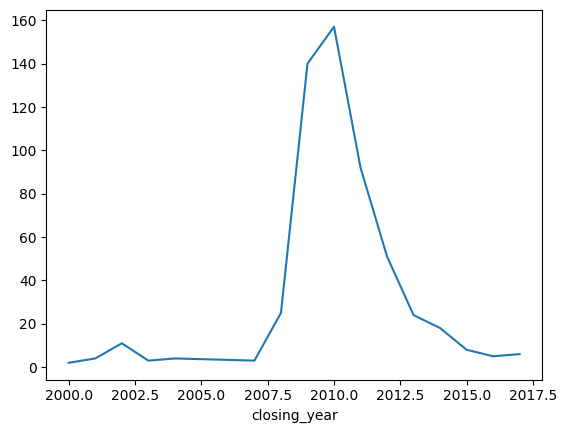

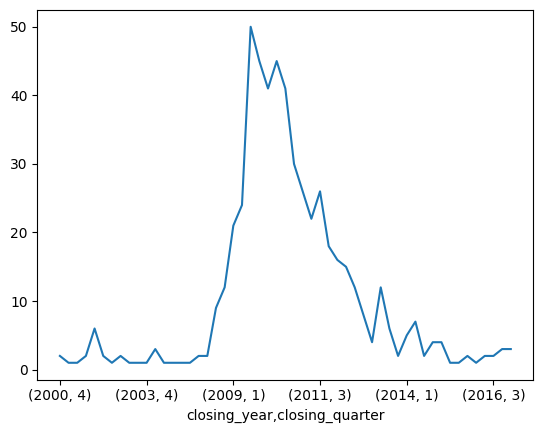

In [53]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax = closing_year.plot()
plt.show()

fig, ax = plt.subplots()
ax = closing_year_q.plot()
plt.show()

In [54]:
pip install pandas-datareader

In [55]:
pd.core.common.is_list_like = pd.api.types.is_list_like
import pandas_datareader as pdr

In [58]:
from google.colab import files
uploaded = files.upload()

Saving tesla_stock_quandl.csv to tesla_stock_quandl.csv


In [72]:
tesla = pd.read_csv('tesla_stock_quandl.csv')

In [73]:
print(tesla.head( ))

        Price               Close                High                Low  \
0      Ticker                TSLA                TSLA               TSLA   
1        Date                 NaN                 NaN                NaN   
2  2021-03-22   223.3333282470703   233.2066650390625  222.9166717529297   
3  2021-03-23  220.72000122070312  225.93333435058594  219.1699981689453   
4  2021-03-24  210.08999633789062     222.67333984375  210.0366668701172   

                 Open     Volume  
0                TSLA       TSLA  
1                 NaN        NaN  
2  228.19667053222656  118536600  
3   225.2566680908203   91475700  
4   222.6366729736328  101385600  


In [84]:
#Date 열을 Datetime 형으로 번환
tesla = pd.read_csv('tesla_stock_quandl.csv', parse_dates=[0])
print(tesla.info( ))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1258 non-null   object
 1   Close   1257 non-null   object
 2   High    1257 non-null   object
 3   Low     1257 non-null   object
 4   Open    1257 non-null   object
 5   Volume  1257 non-null   object
dtypes: object(6)
memory usage: 59.1+ KB
None


/tmp/ipykernel_14831/3830061211.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tesla = pd.read_csv('tesla_stock_quandl.csv', parse_dates=[0])


In [93]:
tesla = pd.read_csv('tesla_stock_quandl.csv')
tesla = tesla.rename(columns={'Price': 'Date'})
tesla = tesla[~tesla['Date'].isin(['Ticker', 'Date'])]
tesla['Date'] = pd.to_datetime(tesla['Date'])

for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    tesla[col] = pd.to_numeric(tesla[col])

tesla = tesla.set_index('Date')

print(tesla.loc[(tesla.index.year == 2025) & (tesla.index.month == 5)])

                 Close        High         Low        Open     Volume
Date                                                                 
2025-05-01  280.519989  290.869995  279.809998  280.010010   99659000
2025-05-02  287.209991  294.779999  279.809998  284.899994  114454700
2025-05-05  280.260010  284.850006  274.399994  284.570007   94618900
2025-05-06  275.350006  277.730011  271.350006  273.109985   76715800
2025-05-07  276.220001  277.920013  271.000000  276.880005   71592600
2025-05-08  284.820007  289.799988  279.410004  279.630005   97539400
2025-05-09  298.260010  307.040009  290.000000  290.209991  132387800
2025-05-12  318.380005  322.209991  311.500000  321.989990  112826700
2025-05-13  334.070007  337.589996  316.799988  320.000000  136992600
2025-05-14  347.679993  350.000000  337.000000  342.500000  136997300
2025-05-15  342.820007  346.140015  334.720001  340.339996   97882600
2025-05-16  349.980011  351.619995  342.329987  346.239990   95895700
2025-05-19  342.0899

In [95]:
print(tesla.index)

DatetimeIndex(['2021-03-22', '2021-03-23', '2021-03-24', '2021-03-25',
               '2021-03-26', '2021-03-29', '2021-03-30', '2021-03-31',
               '2021-04-01', '2021-04-05',
               ...
               '2026-03-09', '2026-03-10', '2026-03-11', '2026-03-12',
               '2026-03-13', '2026-03-16', '2026-03-17', '2026-03-18',
               '2026-03-19', '2026-03-20'],
              dtype='datetime64[ns]', name='Date', length=1256, freq=None)


In [100]:
print(tesla.loc['2023'].iloc[:5, :5])

                 Close        High         Low        Open     Volume
Date                                                                 
2023-01-03  108.099998  118.800003  104.639999  118.470001  231402800
2023-01-04  113.639999  114.589996  107.519997  109.110001  180389000
2023-01-05  110.339996  111.750000  107.160004  110.510002  157986300
2023-01-06  113.059998  114.389999  101.809998  103.000000  220911100
2023-01-09  119.769997  123.519997  117.110001  118.959999  190284000


In [102]:
print(tesla.loc['2024-06'].iloc[:, :5])

                 Close        High         Low        Open     Volume
Date                                                                 
2024-06-03  176.289993  182.639999  174.490005  178.130005   68568900
2024-06-04  174.770004  177.759995  174.000000  174.779999   60056300
2024-06-05  175.000000  176.149994  172.130005  175.350006   57953800
2024-06-06  177.940002  179.729996  172.729996  174.600006   69887000
2024-06-07  177.479996  179.350006  175.580002  176.130005   56244900
2024-06-10  173.789993  178.570007  173.169998  176.059998   50774600
2024-06-11  170.660004  174.750000  167.410004  173.919998   64761900
2024-06-12  177.289993  180.550003  169.800003  171.119995   90389400
2024-06-13  182.470001  191.080002  181.229996  188.389999  118984100
2024-06-14  178.009995  186.000000  176.919998  185.800003   82038200
2024-06-17  187.440002  188.809998  177.000000  177.919998  109786100
2024-06-18  184.860001  187.199997  182.369995  186.559998   68982300
2024-06-20  181.5700

In [106]:
#시간 간격을 인덱스로 지정해 데이터 추출하기
tesla['ref_date'] = (tesla.index - tesla.index.min()).days
print(tesla.head())

                 Close        High         Low        Open     Volume  \
Date                                                                    
2021-03-22  223.333328  233.206665  222.916672  228.196671  118536600   
2021-03-23  220.720001  225.933334  219.169998  225.256668   91475700   
2021-03-24  210.089996  222.673340  210.036667  222.636673  101385600   
2021-03-25  213.463333  215.166672  203.166672  204.333328  117674700   
2021-03-26  206.236664  214.606674  199.963333  213.956665  101558400   

            ref_date  
Date                  
2021-03-22         0  
2021-03-23         1  
2021-03-24         2  
2021-03-25         3  
2021-03-26         4  


In [108]:
tesla.index = tesla['ref_date']
print(tesla.iloc[:5, :5])

               Close        High         Low        Open     Volume
ref_date                                                           
0         223.333328  233.206665  222.916672  228.196671  118536600
1         220.720001  225.933334  219.169998  225.256668   91475700
2         210.089996  222.673340  210.036667  222.636673  101385600
3         213.463333  215.166672  203.166672  204.333328  117674700
4         206.236664  214.606674  199.963333  213.956665  101558400


In [110]:
print(tesla[5:].iloc[:5, :5])

               Close        High         Low        Open     Volume
ref_date                                                           
7         203.763336  205.493332  198.673340  205.213333   85911000
8         211.873337  212.553329  197.003326  200.583328  118297200
9         222.643326  224.000000  213.703339  215.539993  100011900
10        220.583328  230.806671  219.806671  229.456665  105895200
14        230.350006  236.053329  228.233337  235.903336  125528400


In [112]:
#시간 범위 생성해 인덱스로 지정하기
ebola = pd.read_csv('country_timeseries.csv', parse_dates=[0])
print(ebola.iloc[:5, :5])

        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0


In [113]:
print(ebola.iloc[-5:, :5])

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117 2014-03-27    5         103.0            8.0                6.0
118 2014-03-26    4          86.0            NaN                NaN
119 2014-03-25    3          86.0            NaN                NaN
120 2014-03-24    2          86.0            NaN                NaN
121 2014-03-22    0          49.0            NaN                NaN


In [114]:
head_range = pd.date_range(start='2014-12-31', end='2015-01-05')
print(head_range)

DatetimeIndex(['2014-12-31', '2015-01-01', '2015-01-02', '2015-01-03',
               '2015-01-04', '2015-01-05'],
              dtype='datetime64[ns]', freq='D')


원본 데이터를 손상시키지 않기 위해 새로운 데이터프레임을 만들때 Date열을 인덱스로 먼저 지정하지 않으면 오류가 발생함

In [115]:
ebola_5 = ebola.head( )
ebola_5.index = ebola_5['Date']
ebola_5.reindex(head_range)
print(ebola_5.iloc[:5, :5])

                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
Date                                                                      
2015-01-05 2015-01-05  289        2776.0            NaN            10030.0
2015-01-04 2015-01-04  288        2775.0            NaN             9780.0
2015-01-03 2015-01-03  287        2769.0         8166.0             9722.0
2015-01-02 2015-01-02  286           NaN         8157.0                NaN
2014-12-31 2014-12-31  284        2730.0         8115.0             9633.0



 B     - 평일만 포함                               
 C     - 사용자가 정의한 평일만 포함                         
 D     - 달력 일자 단위                                
 W     - 주간 단위                                   
 M     - 월 마지막 날만 포함                             
 SM    - 15일과 월 마지막 날만 포함                        
 BM    - M 주기의 값이 휴일이면 제외하고 평일만 포함               
 CBM   - BM에 사용자 정의 평일을 적용                       
 MS    - 월 시작일만 포함                               
 SMS   - 월 시작일과 15일만 포함                         
 BMS   - MS 주기의 값이 휴일이면 제외하고 평일만 포함              
 CBMS  - BMS에 사용자 정의 평일을 적용                      
 Q     - 3, 6, 9, 12월 분기 마지막 날만 포함               
 BQ    - 3, 6, 9, 12월 분기 마지막 날이 휴일이면 제외하고 평일만 포함
 QS    - 3, 6, 9, 12월 분기 시작일만 포함                 
 BQS   - 3, 6, 9, 12월 분기 시작일이 휴일이면 제외하고 평일만 포함   
 A     - 년의 마지막 날만 포함                            
 BA    - 년의 마지막 날이 휴일이면 제외하고 평일만 포함              
 AS    - 년의 시작일만 포함                              
 BAS   - 년의 시작일이 휴일이면 제외하고 평일만 포함                
 BH    - 평일을 시간 단위로 포함(09:00 ~ 16:00)            
 H     - 시간 단위로 포함(00:00 ~ 00:00)                
 T     - 분 단위 포함    
 S     - 초 단위 포함     
 L     - 밀리초 단위 포함   
 U     - 마이크로초 단위 포함  
 N     - 나노초 단위 포함   

In [116]:
print(pd.date_range('2017-01-01', '2017-01-07', freq='B'))

DatetimeIndex(['2017-01-02', '2017-01-03', '2017-01-04', '2017-01-05',
               '2017-01-06'],
              dtype='datetime64[ns]', freq='B')


###시간 범위 수정하고 데이터 밀어내기 - shift 메서드

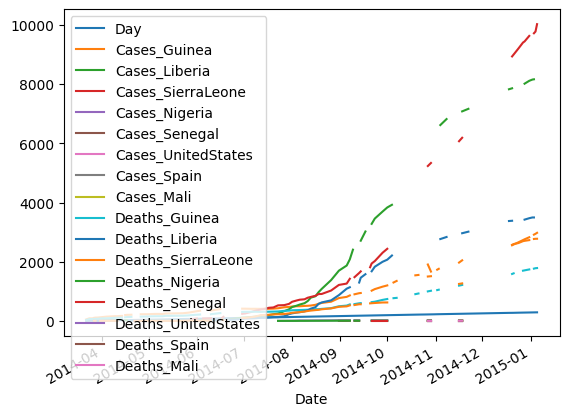

In [118]:
#에볼라의 확산 속도 비교하기
ebola.index = ebola['Date']
fig, ax = plt.subplots( )
ax = ebola.iloc[0:, 1:].plot(ax=ax)

In [121]:
ebola_sub = ebola[['Day', 'Cases_Guinea', 'Cases_Liberia']]
print(ebola_sub.tail(10))

            Day  Cases_Guinea  Cases_Liberia
Date                                        
2014-04-04   13         143.0           18.0
2014-04-01   10         127.0            8.0
2014-03-31    9         122.0            8.0
2014-03-29    7         112.0            7.0
2014-03-28    6         112.0            3.0
2014-03-27    5         103.0            8.0
2014-03-26    4          86.0            NaN
2014-03-25    3          86.0            NaN
2014-03-24    2          86.0            NaN
2014-03-22    0          49.0            NaN


In [122]:
ebola = pd.read_csv('country_timeseries.csv', parse_dates=['Date'])
print(ebola.head( ).iloc[:, :5])

        Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
0 2015-01-05  289        2776.0            NaN            10030.0
1 2015-01-04  288        2775.0            NaN             9780.0
2 2015-01-03  287        2769.0         8166.0             9722.0
3 2015-01-02  286           NaN         8157.0                NaN
4 2014-12-31  284        2730.0         8115.0             9633.0


In [123]:
print(ebola.tail( ).iloc[:, :5])

          Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
117 2014-03-27    5         103.0            8.0                6.0
118 2014-03-26    4          86.0            NaN                NaN
119 2014-03-25    3          86.0            NaN                NaN
120 2014-03-24    2          86.0            NaN                NaN
121 2014-03-22    0          49.0            NaN                NaN


In [125]:
ebola.index = ebola['Date']
new_idx = pd.date_range(ebola.index.min( ), ebola.index.max( ))

In [129]:
#reversed 메서드를 사용하여 인덱스를 반대로 뒤집음
new_idx = reversed(new_idx)
print(new_idx)

In [130]:
ebola = ebola.reindex(new_idx)
print(ebola.head( ).iloc[:, :5])

                 Date    Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
2015-01-05 2015-01-05  289.0        2776.0            NaN            10030.0
2015-01-04 2015-01-04  288.0        2775.0            NaN             9780.0
2015-01-03 2015-01-03  287.0        2769.0         8166.0             9722.0
2015-01-02 2015-01-02  286.0           NaN         8157.0                NaN
2015-01-01        NaT    NaN           NaN            NaN                NaN


In [131]:
print(ebola.tail( ).iloc[:, :5])

                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone
2014-03-26 2014-03-26  4.0          86.0            NaN                NaN
2014-03-25 2014-03-25  3.0          86.0            NaN                NaN
2014-03-24 2014-03-24  2.0          86.0            NaN                NaN
2014-03-23        NaT  NaN           NaN            NaN                NaN
2014-03-22 2014-03-22  0.0          49.0            NaN                NaN


In [132]:
last_valid = ebola.apply(pd.Series.last_valid_index)
print(last_valid)

Date                  2014-03-22
Day                   2014-03-22
Cases_Guinea          2014-03-22
Cases_Liberia         2014-03-27
Cases_SierraLeone     2014-03-27
Cases_Nigeria         2014-07-23
Cases_Senegal         2014-08-31
Cases_UnitedStates    2014-10-01
Cases_Spain           2014-10-08
Cases_Mali            2014-10-22
Deaths_Guinea         2014-03-22
Deaths_Liberia        2014-03-27
Deaths_SierraLeone    2014-03-27
Deaths_Nigeria        2014-07-23
Deaths_Senegal        2014-09-07
Deaths_UnitedStates   2014-10-01
Deaths_Spain          2014-10-08
Deaths_Mali           2014-10-22
dtype: datetime64[ns]


In [133]:
first_valid = ebola.apply(pd.Series.first_valid_index)
print(first_valid)

Date                  2015-01-05
Day                   2015-01-05
Cases_Guinea          2015-01-05
Cases_Liberia         2015-01-03
Cases_SierraLeone     2015-01-05
Cases_Nigeria         2014-12-07
Cases_Senegal         2014-12-07
Cases_UnitedStates    2014-12-07
Cases_Spain           2014-12-07
Cases_Mali            2014-12-07
Deaths_Guinea         2015-01-05
Deaths_Liberia        2015-01-03
Deaths_SierraLeone    2015-01-05
Deaths_Nigeria        2014-12-07
Deaths_Senegal        2014-12-07
Deaths_UnitedStates   2014-12-07
Deaths_Spain          2014-12-07
Deaths_Mali           2014-12-07
dtype: datetime64[ns]


In [134]:
earliest_date = ebola.index.min( )
print(earliest_date)

2014-03-22 00:00:00


In [135]:
shift_values = last_valid - earliest_date
print(shift_values)

Date                    0 days
Day                     0 days
Cases_Guinea            0 days
Cases_Liberia           5 days
Cases_SierraLeone       5 days
Cases_Nigeria         123 days
Cases_Senegal         162 days
Cases_UnitedStates    193 days
Cases_Spain           200 days
Cases_Mali            214 days
Deaths_Guinea           0 days
Deaths_Liberia          5 days
Deaths_SierraLeone      5 days
Deaths_Nigeria        123 days
Deaths_Senegal        169 days
Deaths_UnitedStates   193 days
Deaths_Spain          200 days
Deaths_Mali           214 days
dtype: timedelta64[ns]


In [136]:
#shift 메서드는 인잣값만큼 데이터를 밀어내는 메서드
ebola_dict = {}
for idx, col in enumerate(ebola):
    d = shift_values[idx].days
    shifted = ebola[col].shift(d)
    ebola_dict[col] = shifted

/tmp/ipykernel_14831/231556877.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  d = shift_values[idx].days


In [137]:
ebola_shift = pd.DataFrame(ebola_dict)
print(ebola_shift.tail( ))

                 Date  Day  Cases_Guinea  Cases_Liberia  Cases_SierraLeone  \
2014-03-26 2014-03-26  4.0          86.0            8.0                2.0   
2014-03-25 2014-03-25  3.0          86.0            NaN                NaN   
2014-03-24 2014-03-24  2.0          86.0            7.0                NaN   
2014-03-23        NaT  NaN           NaN            3.0                2.0   
2014-03-22 2014-03-22  0.0          49.0            8.0                6.0   

            Cases_Nigeria  Cases_Senegal  Cases_UnitedStates  Cases_Spain  \
2014-03-26            1.0            NaN                 1.0          1.0   
2014-03-25            NaN            NaN                 NaN          NaN   
2014-03-24            NaN            NaN                 NaN          NaN   
2014-03-23            NaN            NaN                 NaN          NaN   
2014-03-22            0.0            1.0                 1.0          1.0   

            Cases_Mali  Deaths_Guinea  Deaths_Liberia  Deaths_Sierra

In [139]:
#그래프에 필요 없는 Date, Day 열 삭제
ebola_shift.index = ebola_shift['Day']
ebola_shift = ebola_shift.drop(['Date', 'Day'], axis = 1)

print(ebola_shift.tail())

     Cases_Guinea  Cases_Liberia  Cases_SierraLeone  Cases_Nigeria  \
Day                                                                  
4.0          86.0            8.0                2.0            1.0   
3.0          86.0            NaN                NaN            NaN   
2.0          86.0            7.0                NaN            NaN   
NaN           NaN            3.0                2.0            NaN   
0.0          49.0            8.0                6.0            0.0   

     Cases_Senegal  Cases_UnitedStates  Cases_Spain  Cases_Mali  \
Day                                                               
4.0            NaN                 1.0          1.0         NaN   
3.0            NaN                 NaN          NaN         NaN   
2.0            NaN                 NaN          NaN         NaN   
NaN            NaN                 NaN          NaN         NaN   
0.0            1.0                 1.0          1.0         1.0   

     Deaths_Guinea  Deaths_Liberia  Dea

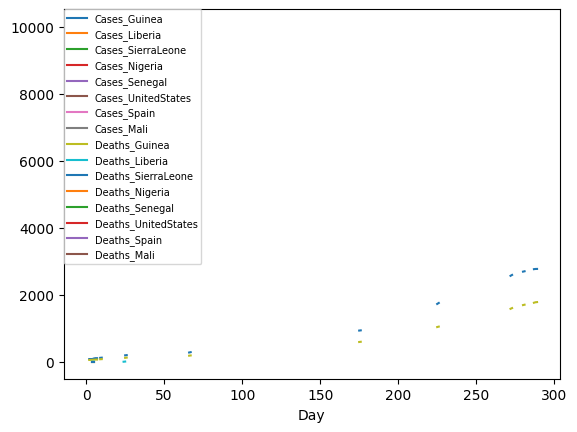

In [142]:
fig, ax = plt.subplots()
ax = ebola_shift.iloc[:,:].plot(ax=ax)
ax.legend(fontsize=7, loc=2, borderaxespad=0.)
plt.show()